# Exploration des Données & Transformations RFM — Pas à Pas

## Présentation du projet

Ce notebook vous guide à travers **l'exploration des données** et les **transformations RFM** (Récence, Fréquence, Montant) du pipeline ETL du projet.

### Les données : Online Retail II (UCI)

Les données proviennent du dataset **"Online Retail II"** de l'UCI Machine Learning Repository. Il s'agit de **transactions d'un commerce en ligne** basé au Royaume-Uni, couvrant la période **2009-2010**.

### Description des colonnes

| Colonne | Description |
|---------|-------------|
| **Invoice** | Numéro de facture (les factures commençant par "C" sont des annulations) |
| **StockCode** | Code produit |
| **Description** | Nom/description du produit |
| **Quantity** | Quantité achetée (négatif = retour) |
| **InvoiceDate** | Date et heure de la transaction |
| **Price** | Prix unitaire du produit (en livres sterling) |
| **Customer ID** | Identifiant unique du client |
| **Country** | Pays du client |

### Pipeline ETL
```
CSV (données brutes) → Nettoyage → Calcul RFM → Stockage PostgreSQL
```

## 1. Import des bibliothèques nécessaires

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Bibliothèques importées avec succès")

✅ Bibliothèques importées avec succès


## 2. Chargement des données brutes

On charge les deux fichiers CSV (2009 et 2010) depuis le dossier `data/raw/` et on les combine en un seul DataFrame.

In [2]:
# Chemin vers les données brutes
data_path = "../data/raw/"

# Charger les deux fichiers CSV
df_2009 = pd.read_csv(os.path.join(data_path, "online_retail_II-2009.csv"), sep=";", encoding="utf-8", decimal=",")
df_2010 = pd.read_csv(os.path.join(data_path, "online_retail_II-2010.csv"), sep=";", encoding="utf-8", decimal=",")

print(f"📂 Fichier 2009 : {df_2009.shape[0]} lignes, {df_2009.shape[1]} colonnes")
print(f"📂 Fichier 2010 : {df_2010.shape[0]} lignes, {df_2010.shape[1]} colonnes")

# Combiner les deux fichiers
df = pd.concat([df_2009, df_2010], ignore_index=True)
print(f"\n📊 Dataset combiné : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Afficher les premières lignes
df.head(10)

📂 Fichier 2009 : 525461 lignes, 8 colonnes
📂 Fichier 2010 : 541910 lignes, 8 colonnes

📊 Dataset combiné : 1067371 lignes, 8 colonnes


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01/12/2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01/12/2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01/12/2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01/12/2009 07:45,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,01/12/2009 07:45,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,01/12/2009 07:45,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,01/12/2009 07:45,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,01/12/2009 07:46,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,01/12/2009 07:46,3.75,13085.0,United Kingdom


## 3. Aperçu général des données

Comprenons la structure du jeu de données : nombre de lignes, colonnes, types de chaque variable.

In [3]:
# Structure du dataset
print("=" * 60)
print("STRUCTURE DU DATASET")
print("=" * 60)
print(f"\n🔢 Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"\n📋 Colonnes : {list(df.columns)}")
print(f"\n📌 Types de données :")
print(df.dtypes)
print(f"\n📝 Informations détaillées :")
df.info()

STRUCTURE DU DATASET

🔢 Dimensions : 1067371 lignes × 8 colonnes

📋 Colonnes : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

📌 Types de données :
Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

📝 Informations détaillées :
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1),

## 4. Statistiques descriptives

Observons les distributions, moyennes, médianes, min/max et quartiles pour les colonnes numériques et catégorielles.

In [4]:
# Statistiques descriptives - colonnes numériques
print("📊 Statistiques descriptives (numériques) :")
df.describe()

📊 Statistiques descriptives (numériques) :


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [5]:
# Statistiques descriptives - colonnes catégorielles
print("📊 Statistiques descriptives (catégorielles) :")
df.describe(include='object')

📊 Statistiques descriptives (catégorielles) :


,Invoice,StockCode,Description,InvoiceDate,Country
count,1067371,1067371,1062989,1067371,1067371
unique,53628,5305,5698,47635,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,06/12/2010 16:57,United Kingdom
freq,1350,5829,5918,1350,981330


## 5. Vérification des valeurs manquantes et doublons

Détectons les valeurs manquantes et les doublons dans le dataset.

🔍 Valeurs manquantes par colonne :
             Manquantes  Pourcentage (%)
Invoice               0             0.00
StockCode             0             0.00
Description        4382             0.41
Quantity              0             0.00
InvoiceDate           0             0.00
Price                 0             0.00
Customer ID      243007            22.77
Country               0             0.00


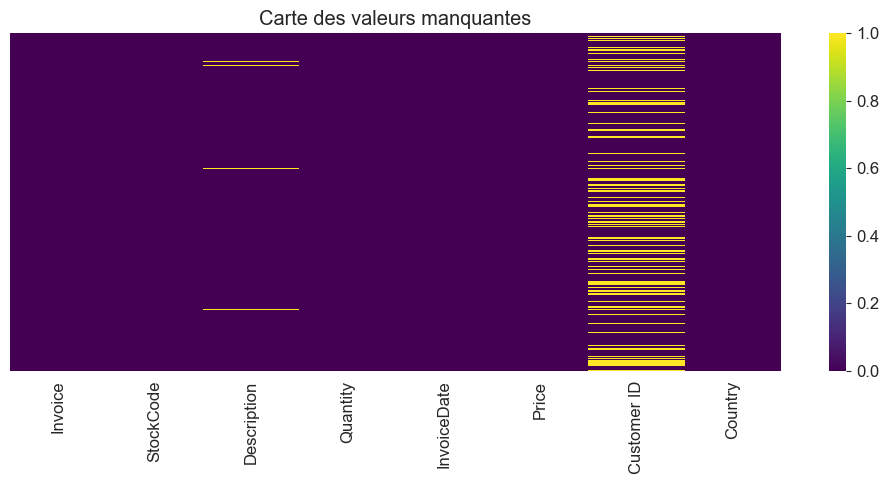


🔁 Nombre de doublons : 34335 (3.22%)


In [6]:
# Valeurs manquantes
print("🔍 Valeurs manquantes par colonne :")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquantes': missing, 'Pourcentage (%)': missing_pct})
print(missing_df)

# Visualisation des valeurs manquantes
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title("Carte des valeurs manquantes")
plt.tight_layout()
plt.show()

# Doublons
nb_doublons = df.duplicated().sum()
print(f"\n🔁 Nombre de doublons : {nb_doublons} ({nb_doublons/len(df)*100:.2f}%)")

## 6. Exploration des colonnes clés

Analysons les colonnes essentielles pour le calcul RFM : **Customer ID**, **InvoiceDate**, **Price** et **Quantity**.

👤 Nombre de clients uniques : 5942
   (dont 243007 lignes sans Customer ID)

🧾 Nombre de factures uniques : 53628

🌍 Nombre de pays : 43

🏆 Top 10 des pays par nombre de transactions :
Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64


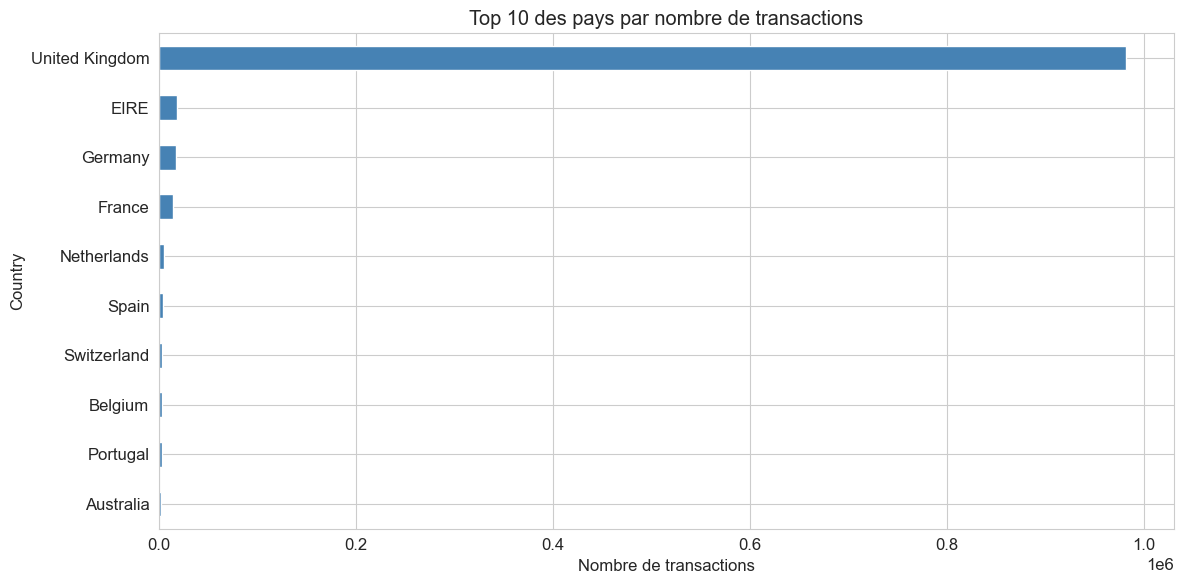

In [7]:
# Nombre de clients uniques
print(f"👤 Nombre de clients uniques : {df['Customer ID'].nunique()}")
print(f"   (dont {df['Customer ID'].isnull().sum()} lignes sans Customer ID)")

# Nombre de factures uniques
print(f"\n🧾 Nombre de factures uniques : {df['Invoice'].nunique()}")

# Nombre de pays
print(f"\n🌍 Nombre de pays : {df['Country'].nunique()}")

# Top 10 des pays par nombre de transactions
print("\n🏆 Top 10 des pays par nombre de transactions :")
top_pays = df['Country'].value_counts().head(10)
print(top_pays)

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
top_pays.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title("Top 10 des pays par nombre de transactions")
ax.set_xlabel("Nombre de transactions")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Distribution des variables numériques

Traçons des histogrammes et boxplots pour les colonnes **Quantity** et **Price** afin de détecter les outliers.

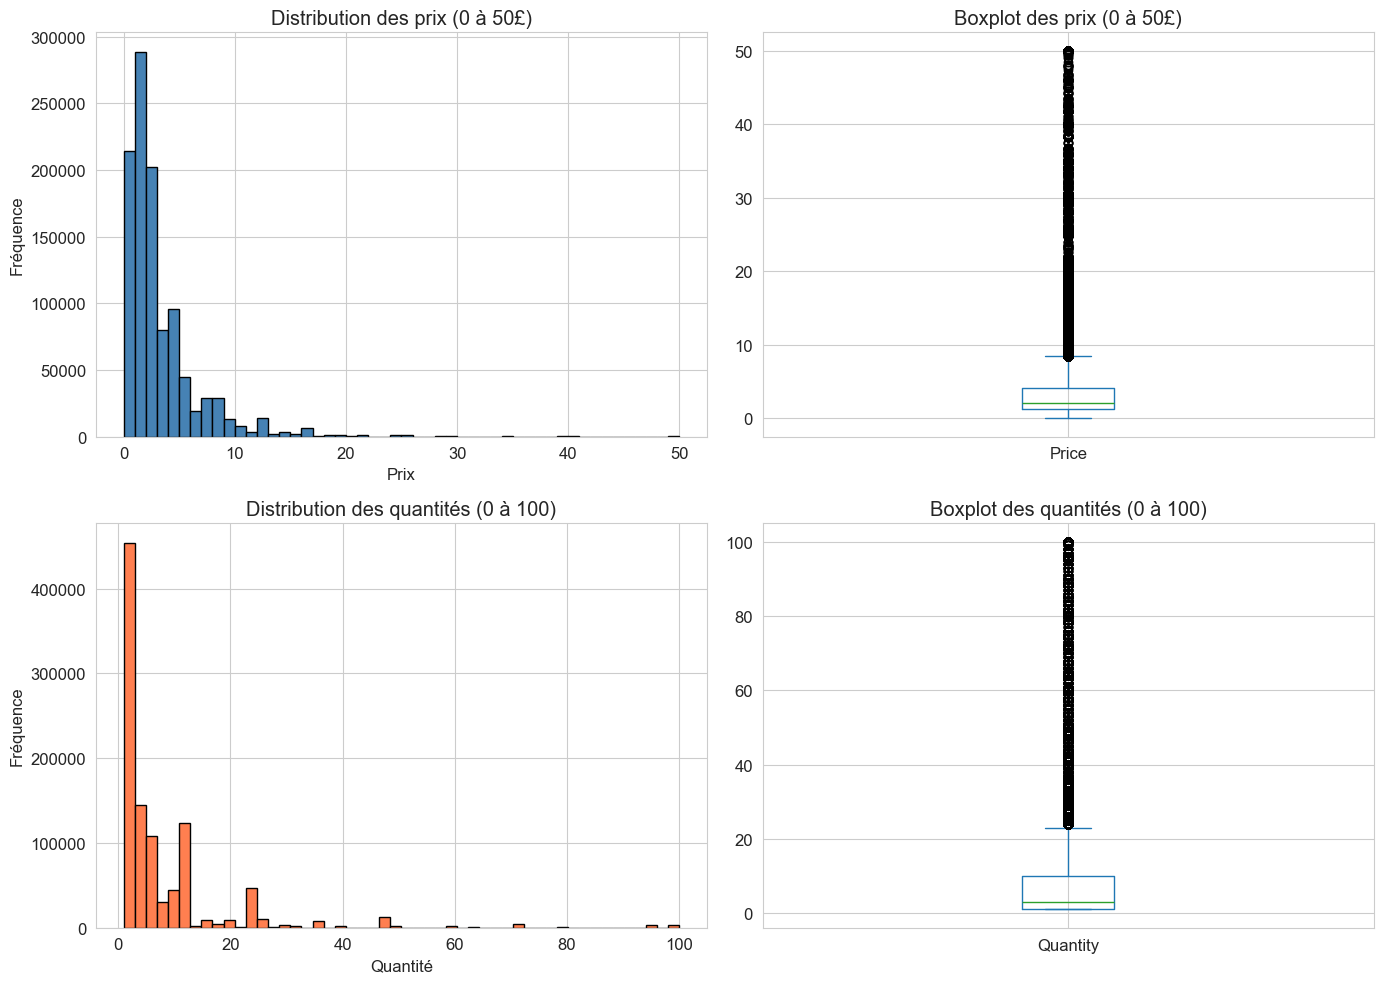

⚠️ Lignes avec quantités négatives : 22950
⚠️ Lignes avec prix négatifs ou nuls : 6207


In [8]:
# Conversion du Prix en numérique si nécessaire
if df["Price"].dtype == object:
    df["Price"] = df["Price"].astype(str).str.replace(",", ".").astype(float)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogramme des prix (filtré pour lisibilité)
df[df['Price'].between(0, 50)]['Price'].hist(bins=50, ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title("Distribution des prix (0 à 50£)")
axes[0, 0].set_xlabel("Prix")
axes[0, 0].set_ylabel("Fréquence")

# Boxplot des prix
df[df['Price'].between(0, 50)]['Price'].plot(kind='box', ax=axes[0, 1])
axes[0, 1].set_title("Boxplot des prix (0 à 50£)")

# Histogramme des quantités (filtré)
df[df['Quantity'].between(0, 100)]['Quantity'].hist(bins=50, ax=axes[1, 0], color='coral', edgecolor='black')
axes[1, 0].set_title("Distribution des quantités (0 à 100)")
axes[1, 0].set_xlabel("Quantité")
axes[1, 0].set_ylabel("Fréquence")

# Boxplot des quantités
df[df['Quantity'].between(0, 100)]['Quantity'].plot(kind='box', ax=axes[1, 1])
axes[1, 1].set_title("Boxplot des quantités (0 à 100)")

plt.tight_layout()
plt.show()

# Valeurs aberrantes
print(f"⚠️ Lignes avec quantités négatives : {(df['Quantity'] < 0).sum()}")
print(f"⚠️ Lignes avec prix négatifs ou nuls : {(df['Price'] <= 0).sum()}")

---

# Transformations pas à pas

## Étape 1 : Nettoyage des données

Le nettoyage comprend :
1. **Conversion des dates** au format datetime
2. **Suppression des doublons**
3. **Suppression des lignes sans Customer ID** (indispensable pour le RFM)
4. **Filtrage des annulations** (factures commençant par "C")
5. **Filtrage des quantités et prix négatifs/nuls**

In [9]:
# On travaille sur une copie pour ne pas altérer les données brutes
df_clean = df.copy()
print(f"📊 Données de départ : {len(df_clean)} lignes")

# 1. Conversion de la date
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], format='%d/%m/%Y %H:%M', errors='coerce')
print(f"   ✅ Dates converties en datetime")

# 2. Suppression des doublons
avant = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"   ✅ Doublons supprimés : {avant - len(df_clean)} lignes retirées → {len(df_clean)} lignes restantes")

# 3. Suppression des lignes sans Customer ID
avant = len(df_clean)
df_clean = df_clean.dropna(subset=['Customer ID'])
print(f"   ✅ Lignes sans Customer ID supprimées : {avant - len(df_clean)} lignes retirées → {len(df_clean)} lignes restantes")

# 4. Filtrage des annulations (factures commençant par "C")
avant = len(df_clean)
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print(f"   ✅ Annulations filtrées : {avant - len(df_clean)} lignes retirées → {len(df_clean)} lignes restantes")

# 5. Filtrage des quantités et prix négatifs/nuls
avant = len(df_clean)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print(f"   ✅ Quantités/prix négatifs filtrés : {avant - len(df_clean)} lignes retirées → {len(df_clean)} lignes restantes")

print(f"\n📊 Données après nettoyage : {len(df_clean)} lignes")
df_clean.head()

📊 Données de départ : 1067371 lignes
   ✅ Dates converties en datetime
   ✅ Doublons supprimés : 34335 lignes retirées → 1033036 lignes restantes
   ✅ Lignes sans Customer ID supprimées : 235151 lignes retirées → 797885 lignes restantes
   ✅ Annulations filtrées : 18390 lignes retirées → 779495 lignes restantes
   ✅ Quantités/prix négatifs filtrés : 70 lignes retirées → 779425 lignes restantes

📊 Données après nettoyage : 779425 lignes


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Étape 2 : Calcul de la Récence (R)

La **Récence** mesure **combien de jours se sont écoulés depuis le dernier achat** d'un client.

- Plus la récence est **faible**, plus le client est **récent** (bon signe).
- On utilise la date maximale du dataset comme date de référence.

📅 Date de référence : 2011-12-10 12:50:00

📊 Récence calculée pour 5878 clients
   Customer ID  Recency
0      12346.0      326
1      12347.0        2
2      12348.0       75
3      12349.0       19
4      12350.0      310
5      12351.0      375
6      12352.0       36
7      12353.0      204
8      12354.0      232
9      12355.0      214


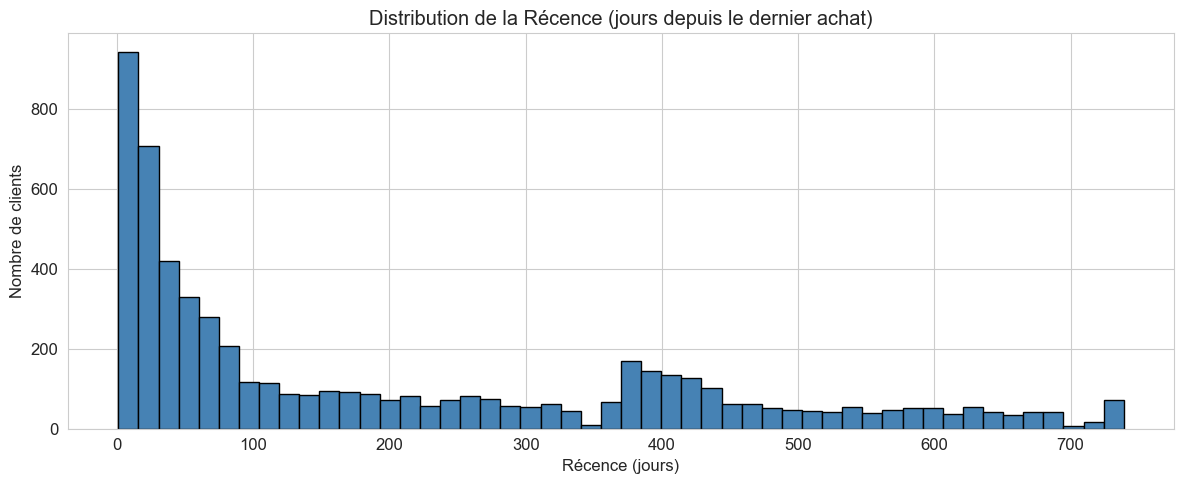

In [10]:
# Date de référence = date max du dataset + 1 jour
date_reference = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"📅 Date de référence : {date_reference}")

# Calcul de la Récence par client
recency = df_clean.groupby('Customer ID')['InvoiceDate'].max().reset_index()
recency['Recency'] = (date_reference - recency['InvoiceDate']).dt.days
recency = recency[['Customer ID', 'Recency']]

print(f"\n📊 Récence calculée pour {len(recency)} clients")
print(recency.head(10))

# Distribution de la Récence
fig, ax = plt.subplots(figsize=(12, 5))
recency['Recency'].hist(bins=50, color='steelblue', edgecolor='black', ax=ax)
ax.set_title("Distribution de la Récence (jours depuis le dernier achat)")
ax.set_xlabel("Récence (jours)")
ax.set_ylabel("Nombre de clients")
plt.tight_layout()
plt.show()

## Étape 3 : Calcul de la Fréquence (F)

La **Fréquence** mesure le **nombre de transactions distinctes** d'un client.

- Plus la fréquence est **élevée**, plus le client achète **souvent**.

📊 Fréquence calculée pour 5878 clients
   Customer ID  Frequency
0      12346.0         12
1      12347.0          8
2      12348.0          5
3      12349.0          4
4      12350.0          1
5      12351.0          1
6      12352.0         10
7      12353.0          2
8      12354.0          1
9      12355.0          2


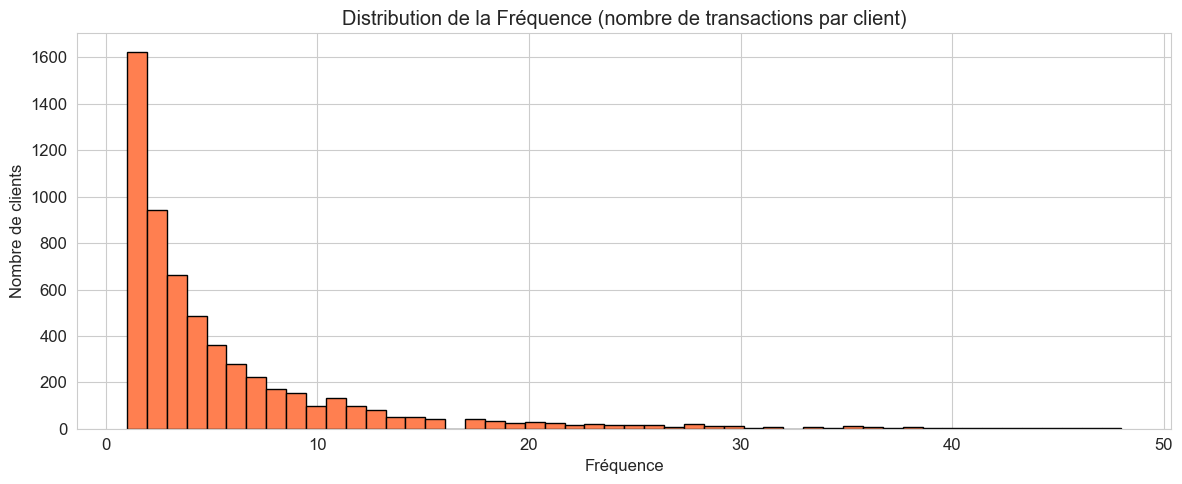

In [11]:
# Calcul de la Fréquence par client (nombre de factures distinctes)
frequency = df_clean.groupby('Customer ID')['Invoice'].nunique().reset_index()
frequency.columns = ['Customer ID', 'Frequency']

print(f"📊 Fréquence calculée pour {len(frequency)} clients")
print(frequency.head(10))

# Distribution de la Fréquence
fig, ax = plt.subplots(figsize=(12, 5))
frequency[frequency['Frequency'] <= 50]['Frequency'].hist(bins=50, color='coral', edgecolor='black', ax=ax)
ax.set_title("Distribution de la Fréquence (nombre de transactions par client)")
ax.set_xlabel("Fréquence")
ax.set_ylabel("Nombre de clients")
plt.tight_layout()
plt.show()

## Étape 4 : Calcul du Montant (M — Monetary)

Le **Montant** (Monetary) mesure le **montant total dépensé** par chaque client.

- `Montant = Price × Quantity` pour chaque ligne
- On fait la **somme** par client

📊 Montant calculé pour 5878 clients
   Customer ID  Monetary
0      12346.0  77556.46
1      12347.0   4921.53
2      12348.0   2019.40
3      12349.0   4428.69
4      12350.0    334.40
5      12351.0    300.93
6      12352.0   2849.84
7      12353.0    406.76
8      12354.0   1079.40
9      12355.0    947.61


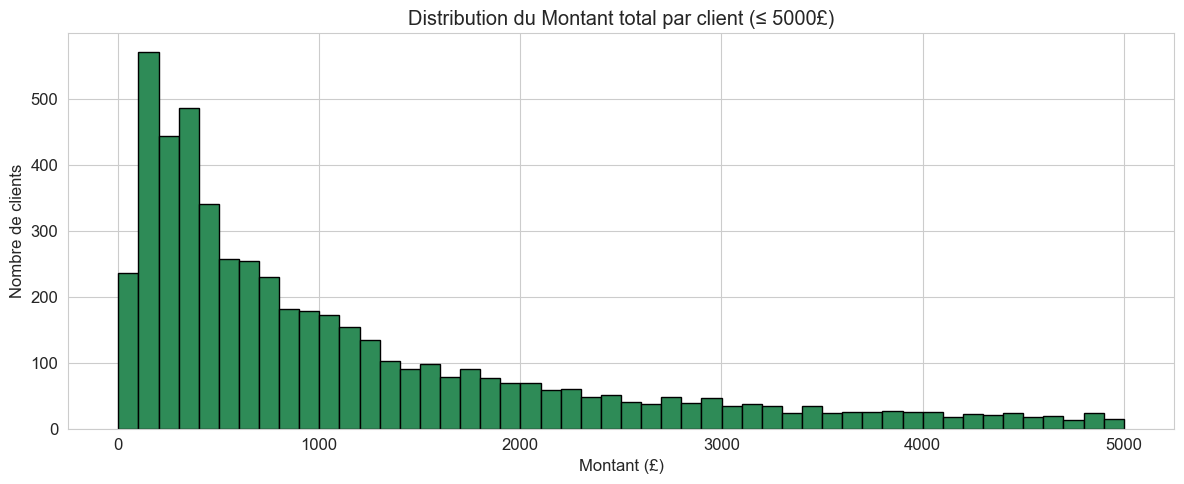

In [12]:
# Calcul du montant par ligne
df_clean['Amount'] = df_clean['Price'] * df_clean['Quantity']

# Montant total par client
monetary = df_clean.groupby('Customer ID')['Amount'].sum().reset_index()
monetary.columns = ['Customer ID', 'Monetary']

# Filtrer les montants négatifs (sécurité)
monetary = monetary[monetary['Monetary'] > 0]

print(f"📊 Montant calculé pour {len(monetary)} clients")
print(monetary.head(10))

# Distribution du Montant
fig, ax = plt.subplots(figsize=(12, 5))
monetary[monetary['Monetary'] <= 5000]['Monetary'].hist(bins=50, color='seagreen', edgecolor='black', ax=ax)
ax.set_title("Distribution du Montant total par client (≤ 5000£)")
ax.set_xlabel("Montant (£)")
ax.set_ylabel("Nombre de clients")
plt.tight_layout()
plt.show()

## Étape 5 : Construction de la table RFM

Fusionnons les trois métriques (**Récence**, **Fréquence**, **Montant**) en un seul DataFrame.

In [13]:
# Fusion des trois métriques RFM
rfm = recency.merge(frequency, on='Customer ID').merge(monetary, on='Customer ID')

print(f"📊 Table RFM finale : {len(rfm)} clients")
print(f"\n📋 Aperçu de la table RFM :")
rfm.head(10)

📊 Table RFM finale : 5878 clients

📋 Aperçu de la table RFM :


,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40
5,12351.0,375,1,300.93
6,12352.0,36,10,2849.84
7,12353.0,204,2,406.76
8,12354.0,232,1,1079.40
9,12355.0,214,2,947.61


In [14]:
# Statistiques descriptives du RFM
print("📊 Statistiques descriptives de la table RFM :")
rfm[['Recency', 'Frequency', 'Monetary']].describe()

📊 Statistiques descriptives de la table RFM :


,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,2955.904095
std,209.338707,13.009406,14440.852688
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,342.280000
50%,96.000000,3.000000,867.740000
75%,380.000000,7.000000,2248.305000
max,739.000000,398.000000,580987.040000


## Étape 6 : Attribution des scores RFM

On utilise `pd.qcut()` pour attribuer un **score de 1 à 5** à chaque métrique.

- **Récence** : score inversé (1 = récent = bien, 5 = ancien = moins bien)
- **Fréquence** : score direct (5 = beaucoup d'achats = bien)
- **Montant** : score direct (5 = gros dépensier = bien)

Le **score RFM global** est la concaténation des trois scores (ex: "555" = meilleur client).

In [15]:
# Attribution des scores de 1 à 5 avec pd.qcut()
# Récence : inversé (5 = client le plus récent, 1 = client le plus ancien)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# Fréquence : direct (5 = le plus fréquent)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Montant : direct (5 = le plus gros dépensier)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Score RFM global (concaténation des trois scores)
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print("📊 Table RFM avec scores :")
rfm.head(10)

📊 Table RFM avec scores :


,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,326,12,77556.46,2,5,5,255
1,12347.0,2,8,4921.53,5,4,5,545
2,12348.0,75,5,2019.40,3,4,4,344
3,12349.0,19,4,4428.69,5,3,5,535
4,12350.0,310,1,334.40,2,1,2,212
5,12351.0,375,1,300.93,2,1,2,212
6,12352.0,36,10,2849.84,4,5,4,454
7,12353.0,204,2,406.76,2,2,2,222
8,12354.0,232,1,1079.40,2,1,3,213
9,12355.0,214,2,947.61,2,2,3,223


## Étape 7 : Segmentation des clients

On définit des **segments clients** en fonction des combinaisons de scores R et F :

| Segment | Condition |
|---------|-----------|
| **Champions** | R ≥ 4 et F ≥ 4 |
| **Clients fidèles** | R ≥ 3 et F ≥ 3 |
| **Potentiels fidèles** | R ≥ 4 et F ≤ 2 |
| **Nouveaux clients** | R ≥ 4 et F = 1 |
| **À risque** | R ≤ 2 et F ≥ 3 |
| **En hibernation** | R ≤ 2 et F ≤ 2 |
| **Perdus** | R = 1 et F = 1 |

In [16]:
# Fonction de segmentation basée sur les scores R et F
def segment_client(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Clients fidèles'
    elif r >= 4 and f <= 2:
        return 'Potentiels fidèles'
    elif r <= 2 and f >= 3:
        return 'À risque'
    elif r <= 2 and f <= 2:
        return 'En hibernation'
    elif r == 1 and f == 1:
        return 'Perdus'
    else:
        return 'Autres'

rfm['Segment'] = rfm.apply(segment_client, axis=1)

# Répartition des segments
print("📊 Répartition des segments clients :")
segment_counts = rfm['Segment'].value_counts()
print(segment_counts)

# Pourcentage
print(f"\n📊 Pourcentage par segment :")
print((segment_counts / len(rfm) * 100).round(1))

📊 Répartition des segments clients :
Segment
En hibernation        1523
Champions             1482
Clients fidèles       1221
À risque               824
Potentiels fidèles     443
Autres                 385
Name: count, dtype: int64

📊 Pourcentage par segment :
Segment
En hibernation        25.9
Champions             25.2
Clients fidèles       20.8
À risque              14.0
Potentiels fidèles     7.5
Autres                 6.5
Name: count, dtype: float64


## Visualisation finale des segments RFM

Graphiques récapitulatifs pour visualiser la répartition des clients par segment et les distributions RFM.

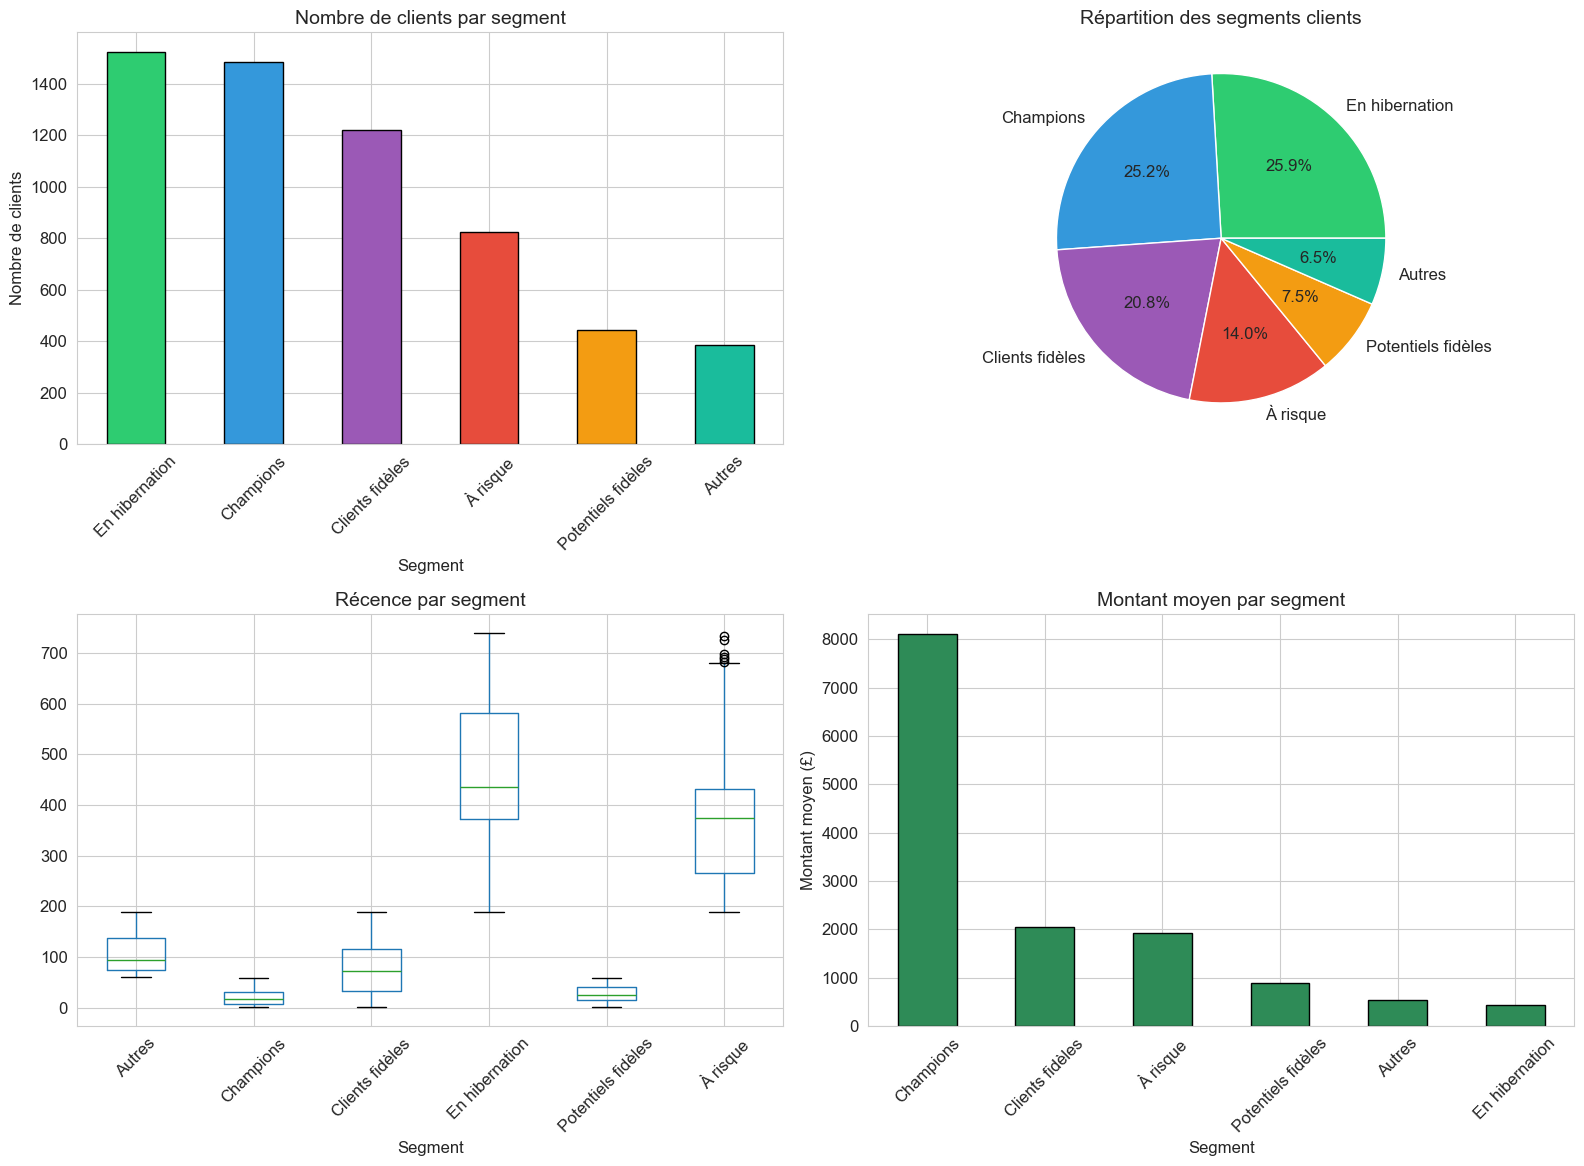

In [17]:
# 1. Bar chart : nombre de clients par segment
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c', '#95a5a6']
segment_counts = rfm['Segment'].value_counts()
segment_counts.plot(kind='bar', color=colors[:len(segment_counts)], edgecolor='black', ax=axes[0, 0])
axes[0, 0].set_title("Nombre de clients par segment", fontsize=14)
axes[0, 0].set_xlabel("Segment")
axes[0, 0].set_ylabel("Nombre de clients")
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Pie chart : répartition des segments
segment_counts.plot(kind='pie', autopct='%1.1f%%', colors=colors[:len(segment_counts)], ax=axes[0, 1])
axes[0, 1].set_title("Répartition des segments clients", fontsize=14)
axes[0, 1].set_ylabel("")

# 3. Boxplot R, F, M par segment
rfm.boxplot(column='Recency', by='Segment', ax=axes[1, 0])
axes[1, 0].set_title("Récence par segment", fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=45)
plt.suptitle("")

# 4. Monetary moyen par segment
rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False).plot(
    kind='bar', color='seagreen', edgecolor='black', ax=axes[1, 1]
)
axes[1, 1].set_title("Montant moyen par segment", fontsize=14)
axes[1, 1].set_xlabel("Segment")
axes[1, 1].set_ylabel("Montant moyen (£)")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

📊 Résumé par segment :
                    Recency  Frequency  Monetary
Segment                                         
Autres                107.1        1.4     530.8
Champions              20.4       15.7    8113.6
Clients fidèles        78.6        5.4    2055.7
En hibernation        459.3        1.3     429.7
Potentiels fidèles     28.1        1.5     885.5
À risque              369.1        4.9    1928.9


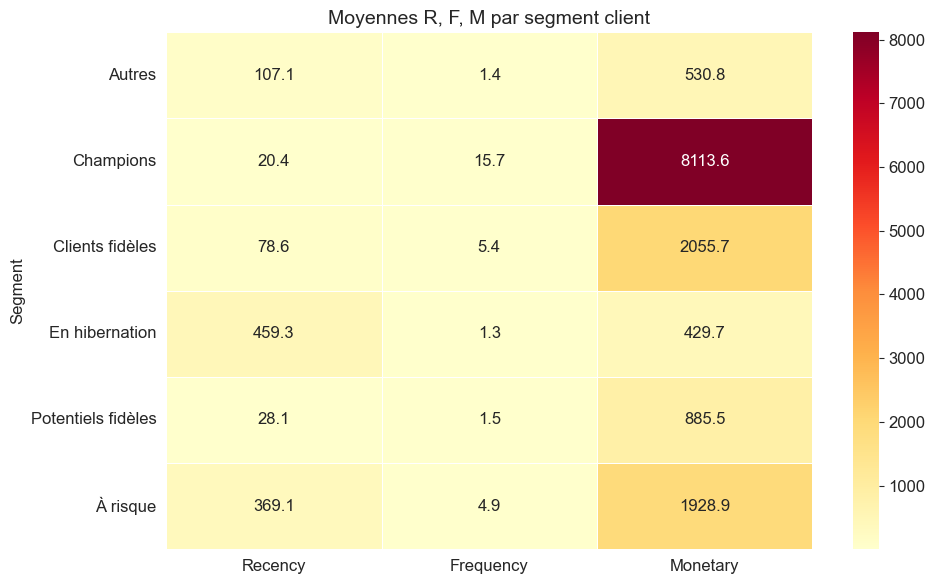

In [18]:
# Heatmap des scores RFM moyens par segment
segment_summary = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
print("📊 Résumé par segment :")
print(segment_summary)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(segment_summary, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title("Moyennes R, F, M par segment client", fontsize=14)
plt.tight_layout()
plt.show()

---

## Résumé du pipeline

```
📂 CSV bruts (2009 + 2010)
   ↓
🧹 Nettoyage : doublons, valeurs manquantes, annulations, prix/quantités négatifs
   ↓
📐 Calcul RFM :
   • Récence  = jours depuis le dernier achat
   • Fréquence = nombre de transactions
   • Montant  = somme des dépenses (Price × Quantity)
   ↓
🏷️ Scoring : attribution de scores 1-5 via pd.qcut()
   ↓
👥 Segmentation : Champions, Fidèles, À risque, Perdus...
   ↓
🐘 Stockage dans PostgreSQL (table rfm_analysis)
```

> **Note :** Dans le pipeline de production (`src/etl/transform.py`), les étapes de scoring et de segmentation ne sont pas incluses. Seules les métriques brutes (Recency, Frequency, Monetary) sont calculées et stockées dans PostgreSQL. Le scoring et la segmentation peuvent être ajoutés comme étape supplémentaire.